# Cluster configuration geometry reconstruction

Predicts the magnetic cluster configuration of a **contracted** binary Bar–Y superlattice from the branch lengths $\mathbf{x} = [L_{0,\mathrm{Bar}},\, L_{0,\mathrm{Y}}]$.

Owing to the rotational symmetry of the clusters, a configuration is described by the centre of a reference Bar unit $(X_{\mathrm{Bar}}, Y_{\mathrm{Bar}})$, the centre of the Y unit above it $(X_{\mathrm{Y}}, Y_{\mathrm{Y}})$ and the two orientation angles $(\theta_{\mathrm{Bar}}, \theta_{\mathrm{Y}})$. A rigid-body rotation places the reference Bar unit on the $x$-axis ($Y_{\mathrm{Bar}} = 0$), leaving five parameters $\mathbf{y} = [X_{\mathrm{Bar}}, X_{\mathrm{Y}}, Y_{\mathrm{Y}}, \theta_{\mathrm{Bar}}, \theta_{\mathrm{Y}}]$ that are predicted jointly. Since a Bar unit is invariant under a rotation of $\pi$, $\theta_{\mathrm{Bar}}$ is given in $(-\pi/2, \pi/2]$ so that it varies continuously across the three configuration types. The full superlattice is recovered by six-fold rotation of the cluster and periodic replication.

* **Data**: the 118 contracted designs (51 Bar-dominant, 35 balanced, 32 Y-dominant), one sheet per type in `data/Supplementary Data 4.xlsx`.
* **Model**: a multi-output Gaussian process regressor (GPyTorch) with a constant mean and an intrinsic-coregionalisation kernel (RBF kernel in a scale kernel, rank-1 coregionalisation matrix).
* **Metric**: the intersection-over-union (IoU) of the reconstructed and the simulated cluster footprints.
* **Model selection**: the GPR is compared with a *k*-NN regressor, a random forest and a polynomial response surface model over 20 random 80/20 splits.
* **Deployment**: the GPR fitted on all 118 designs is saved to `models/gp_cluster_config.pt`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

import mega_utils as mu

mu.apply_plot_style()

N_JOBS = 8
RETRAIN = False        # False: load the saved results and models and only draw the tables and figures; True: retrain everything
TASKS = list(mu.CONFIG_TASKS)

data = mu.load_configuration_all()
X, Y = mu.config_xy(data)
print(f"{len(data)} contracted designs: {dict(data.Type.value_counts())}")
data.head()

118 contracted designs: {'Bar-dominant': 51, 'Balanced': 35, 'Y-dominant': 32}


,L0Bar,L0Y,xB,yB,xY,yY,thetaB,thetaY,Type
0,1.2,1.0,1.745700,0.000000e+00,1.745236,1.008700,0.246370,1.817370,Bar-dominant
1,1.3,1.1,1.831200,0.000000e+00,1.831200,1.057200,0.237000,1.808000,Bar-dominant
2,1.3,1.0,1.691664,8.673617e-19,1.741777,1.008354,0.200921,1.771921,Bar-dominant
3,1.4,1.1,1.795021,0.000000e+00,1.816377,1.047408,0.177125,1.747125,Bar-dominant
4,1.4,1.0,1.768800,0.000000e+00,1.768800,1.021200,0.225000,1.817000,Bar-dominant


## 1. Dataset

One simulated cluster of each configuration type, drawn from its five parameters (grey: Bar units, blue: Y units).

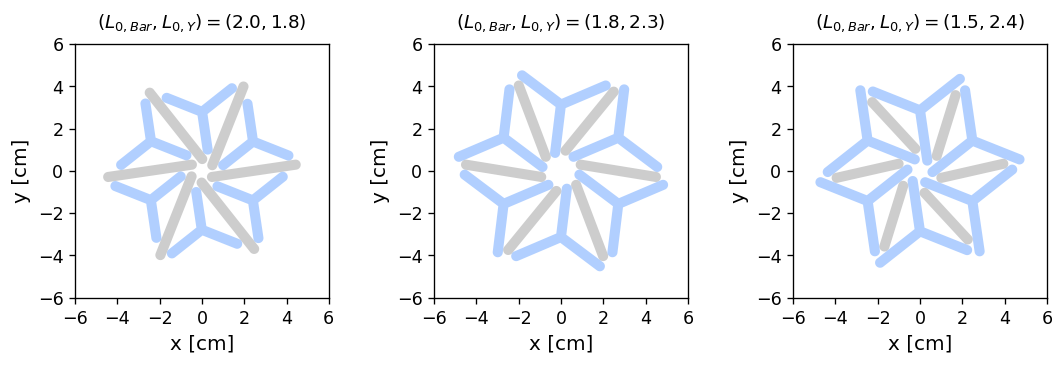

In [2]:
EXAMPLES = {"Bar-dominant": (2.0, 1.8), "Balanced": (1.8, 2.3), "Y-dominant": (1.5, 2.4)}

with mpl.rc_context({"axes.spines.top": True, "axes.spines.right": True}):
    fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.0))
    for ax, (tp, (lb, ly)) in zip(axes, EXAMPLES.items()):
        r = data[(data.Type == tp) & np.isclose(data.L0Bar, lb) & np.isclose(data.L0Y, ly)].iloc[0]
        mu.draw_cluster(ax, r.L0Bar, r.L0Y, r.xB, r.xY, r.yY, r.thetaB, r.thetaY)
        ax.set_aspect("equal"); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
        ax.set_xticks(range(-6, 7, 2)); ax.set_yticks(range(-6, 7, 2))
        ax.set_xlabel("x [cm]"); ax.set_ylabel("y [cm]")
        ax.set_title(f"$(L_{{0,Bar}}, L_{{0,Y}}) = ({lb:.1f}, {ly:.1f})$", pad=10)
    plt.tight_layout(w_pad=2.0)
    plt.show()

## 2. Candidate models

All four models predict the five parameters jointly. The GPR hyperparameters are optimised by marginal-likelihood maximisation; the conventional models are tuned by a five-fold grid search inside the training data of every split:

| model | tuned hyperparameters |
|---|---|
| multi-output GPR | kernel hyperparameters by marginal likelihood (Adam, 300 iterations) |
| *k*-NN | $k \in \{1, 3, 5, 7\}$ |
| random forest | maximum depth $\in \{\text{none}, 4, 8\}$, 400 trees |
| polynomial RSM | degree $\in \{1, 2, 3\}$ |

In [3]:
def make_methods():
    return {
        "GPR": lambda: mu.MultitaskGPSurrogate(iters=300),
        "k-NN": lambda: GridSearchCV(KNeighborsRegressor(), {"n_neighbors": [1, 3, 5, 7]}, cv=5),
        "RF": lambda: GridSearchCV(RandomForestRegressor(n_estimators=400, random_state=42),
                                   {"max_depth": [None, 4, 8]}, cv=5),
        "PRSM": lambda: GridSearchCV(make_pipeline(PolynomialFeatures(), LinearRegression()),
                                     {"polynomialfeatures__degree": [1, 2, 3]}, cv=5),
    }


METHODS = list(make_methods())
print(METHODS)

['GPR', 'k-NN', 'RF', 'PRSM']


## 3. Evaluation over 20 random 80/20 splits

Every model is fitted on the training part of each split and predicts the five parameters of the held-out designs. Each prediction is turned into a reconstructed cluster and scored by its IoU with the simulated cluster (1 = identical footprint). The table reports the mean ± standard deviation of the mean testing IoU over the 20 splits (Supplementary Table 3).

In [4]:
splits = mu.repeated_random(len(data), n_repeats=20, test_size=0.2)


def run_split(sp):
    rows = []
    for name, factory in make_methods().items():
        P = np.asarray(factory().fit(X[sp.train], Y[sp.train]).predict(X[sp.test]), float)
        for r_, i in enumerate(sp.test):
            rec = {"model": name, "split": sp.fold, "point": int(i), "Type": data.Type.iloc[i],
                   "L0Bar": float(X[i, 0]), "L0Y": float(X[i, 1])}
            for j, t in enumerate(TASKS):
                rec[f"true_{t}"], rec[f"pred_{t}"] = float(Y[i, j]), float(P[r_, j])
            rows.append(rec)
    return rows


def row_iou(rec):
    return mu.reconstruction_iou(rec["L0Bar"], rec["L0Y"],
                                 tuple(rec[f"true_{t}"] for t in TASKS), tuple(rec[f"pred_{t}"] for t in TASKS))


if RETRAIN:
    out = Parallel(n_jobs=N_JOBS, max_nbytes=None)(delayed(run_split)(sp) for sp in splits)
    preds = pd.DataFrame([r for rows in out for r in rows])
    preds["IoU"] = Parallel(n_jobs=N_JOBS, max_nbytes=None)(delayed(row_iou)(r) for r in preds.to_dict("records"))
    mu.save_results(preds, "reconstruction_predictions.csv")
else:
    preds = mu.load_results("reconstruction_predictions.csv")

per_split = preds.groupby(["model", "split"]).IoU.mean().rename("IoU").reset_index()
summary = per_split.groupby("model").IoU.agg(["mean", "std", "min", "max"]).loc[METHODS].reset_index()
if RETRAIN:
    mu.save_results(per_split, "reconstruction_iou_per_split.csv")
    mu.save_results(summary, "reconstruction_iou_summary.csv")

table = pd.DataFrame({"Testing IoU": [f"{m:.3f} ± {s:.3f}" for m, s in zip(summary["mean"], summary["std"])]},
                     index=summary.model).T
table

model,GPR,k-NN,RF,PRSM
Testing IoU,0.801 ± 0.016,0.817 ± 0.016,0.778 ± 0.018,0.646 ± 0.029


In [5]:
# per-parameter RMSE of the held-out predictions (positions in cm, angles in degrees), pooled over the 20 splits
rows = []
for name in METHODS:
    g = preds[preds.model == name]
    rec = {"model": name}
    for t in TASKS:
        e = mu.rmse(g[f"true_{t}"], g[f"pred_{t}"])
        rec[f"{t} ({'deg' if t.startswith('theta') else 'cm'})"] = np.degrees(e) if t.startswith("theta") else e
    rows.append(rec)
param_rmse = pd.DataFrame(rows).set_index("model")
if RETRAIN:
    mu.save_results(param_rmse.reset_index(), "reconstruction_parameter_rmse.csv")
param_rmse.round(3)

,xB (cm),xY (cm),yY (cm),thetaB (deg),thetaY (deg)
model,,,,,
GPR,0.114,0.103,0.098,3.206,3.166
k-NN,0.132,0.105,0.102,2.095,2.689
RF,0.135,0.107,0.101,4.304,4.086
PRSM,0.126,0.144,0.103,8.229,7.576


The *k*-NN regressor and the multi-output GPR reach the highest IoU. The GPR is adopted because it provides comparable accuracy together with a predictive uncertainty for the reconstructed configuration.

## 4. Example reconstructions on held-out designs

To visualise the reconstruction quality, the designs are split 80/20 within each type (`random_state=42`) and the GPR is trained on the union of the three training parts. The three held-out designs below are the examples shown in the main text: the filled shapes are the reconstructed clusters, the dashed outlines the simulated ones.

25 held-out designs, mean IoU 0.827


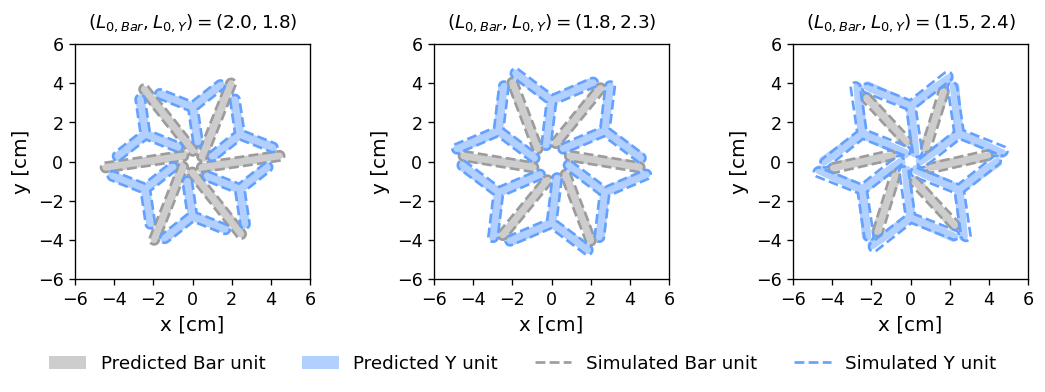

,Type,L0Bar,L0Y,IoU
9,Bar-dominant,2.0,1.8,0.94
16,Balanced,1.8,2.3,0.90
23,Y-dominant,1.5,2.4,0.78


In [6]:
if RETRAIN:
    train_idx, test_idx = [], []
    for tp in mu.CONFIG_SHEETS:
        ids = np.flatnonzero(data.Type.to_numpy() == tp)
        tr, te = train_test_split(np.arange(len(ids)), test_size=0.2, random_state=42)
        train_idx.append(ids[tr]); test_idx.append(ids[te])
    train_idx, test_idx = np.sort(np.concatenate(train_idx)), np.sort(np.concatenate(test_idx))
    P = mu.MultitaskGPSurrogate(iters=300).fit(X[train_idx], Y[train_idx]).predict(X[test_idx])
    held = pd.DataFrame({"point": test_idx, "Type": data.Type.iloc[test_idx].to_numpy(),
                         "L0Bar": X[test_idx, 0], "L0Y": X[test_idx, 1]})
    for j, t in enumerate(TASKS):
        held[f"true_{t}"], held[f"pred_{t}"] = Y[test_idx, j], P[:, j]
    held["IoU"] = [mu.reconstruction_iou(X[i, 0], X[i, 1], tuple(Y[i]), tuple(P[r_])) for r_, i in enumerate(test_idx)]
    mu.save_results(held, "reconstruction_examples_heldout.csv")
else:
    held = mu.load_results("reconstruction_examples_heldout.csv")
print(f"{len(held)} held-out designs, mean IoU {held.IoU.mean():.3f}")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

shown = []
with mpl.rc_context({"axes.spines.top": True, "axes.spines.right": True}):
    fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.0))
    for ax, (tp, (lb, ly)) in zip(axes, EXAMPLES.items()):
        hit = held[(held.Type == tp) & np.isclose(held.L0Bar, lb) & np.isclose(held.L0Y, ly)]
        if len(hit) == 0:   # fall back to the median-IoU held-out design of this type
            hit = held[held.Type == tp].sort_values("IoU").iloc[[len(held[held.Type == tp]) // 2]]
        shown.append(hit)
        r = hit.iloc[0]
        mu.draw_cluster(ax, r.L0Bar, r.L0Y, *[r[f"pred_{t}"] for t in TASKS])
        mu.draw_cluster(ax, r.L0Bar, r.L0Y, *[r[f"true_{t}"] for t in TASKS], outline=True)
        ax.set_aspect("equal"); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
        ax.set_xticks(range(-6, 7, 2)); ax.set_yticks(range(-6, 7, 2))
        ax.set_xlabel("x [cm]"); ax.set_ylabel("y [cm]")
        ax.set_title(f"$(L_{{0,Bar}}, L_{{0,Y}}) = ({r.L0Bar:.1f}, {r.L0Y:.1f})$", pad=10)
    handles = [Patch(fc=mu.GREY, ec="none", alpha=0.5, label="Predicted Bar unit"),
               Patch(fc=mu.BLUE, ec="none", alpha=0.5, label="Predicted Y unit"),
               Line2D([0], [0], c=mu.GREY, lw=1.6, ls="--", label="Simulated Bar unit"),
               Line2D([0], [0], c=mu.BLUE, lw=1.6, ls="--", label="Simulated Y unit")]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=4, frameon=False)
    plt.tight_layout(rect=[0, 0.08, 1, 1], w_pad=2.0)
    plt.show()
pd.concat(shown)[["Type", "L0Bar", "L0Y", "IoU"]].round(2)

## 5. Final model

The GPR is fitted on all 118 contracted designs and saved; `MultitaskGPSurrogate.load` restores it for predictions at new branch lengths (`predict(..., return_std=True)` also returns the predictive standard deviation).

In [7]:
path = f"{mu.MODELS_DIR}/gp_cluster_config.pt"
if RETRAIN:
    mu.MultitaskGPSurrogate(iters=300).fit(X, Y).save(path)

gp_loaded = mu.MultitaskGPSurrogate.load(path)
x_new = np.array([[1.5, 2.0], [1.2, 1.4]])
mean, std = gp_loaded.predict(x_new, return_std=True)
pd.DataFrame(np.column_stack([x_new, mean]), columns=["L0Bar", "L0Y"] + TASKS).round(3)

,L0Bar,L0Y,xB,xY,yY,thetaB,thetaY
0,1.5,2.0,2.419,2.422,1.397,-0.169,1.441
1,1.2,1.4,2.022,2.040,1.164,-0.211,1.408


## Outputs

* `results/reconstruction_predictions.csv` — held-out predictions and IoU of every candidate over the 20 splits.
* `results/reconstruction_iou_per_split.csv`, `results/reconstruction_iou_summary.csv` — Supplementary Table 3.
* `results/reconstruction_parameter_rmse.csv` — per-parameter error of the held-out predictions.
* `models/gp_cluster_config.pt` — the multi-output GPR fitted on all 118 designs.